In [2]:
#Memastikan root directory
import sys
from pathlib import Path

project_root = Path.cwd().parent
assert project_root.name == "digital-twin-lite", f"Root salah: {project_root}"

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd

from src.calibrate import calibrate_params, save_calibration_result
from src.config import SimConfig

In [3]:
#Load data sensor
data_path = project_root / "data" / "raw" / "sensor_log.csv"
df_log = pd.read_csv(data_path)

df_log.head()

,t_s,qin_m3s,qout_m3s,u,L_m,Vg_m3,n_mol,P_Pa,n_in_mols,n_out_mols,dP_liq_Pa,L_true_m,P_true_Pa,L_meas_m,P_meas_Pa,L_missing,P_missing
0,0.0,0.000,0.000000,0.00,1.000000,9.000000,400.000000,118243.555556,0.0,0.000000,0.000000,1.000000,118243.555556,1.003047,118097.697316,False,False
1,0.5,0.004,0.002185,0.55,1.000302,8.999093,396.797146,117308.590686,4.0,10.405708,25257.055556,1.000302,117308.590686,0.989903,117434.658699,False,False
2,1.0,0.004,0.002144,0.55,1.000612,8.998165,393.740097,116416.810548,4.0,10.114098,24324.612785,1.000612,116416.810548,1.008116,116386.091536,False,False
3,1.5,0.004,0.002105,0.55,1.000928,8.997217,390.826148,115567.415151,4.0,9.827898,23435.411330,1.000928,115567.415151,1.010333,115372.246065,False,False
4,2.0,0.004,0.002067,0.55,1.001250,8.996251,388.052484,114759.572474,4.0,9.547327,22588.649598,1.001250,114759.572474,0.981739,114557.308736,False,False


In [4]:
#Menjalankan kalibrasi
sim = SimConfig(dt=0.5, t_end=600.0)

result = calibrate_params(df_log=df_log, sim=sim)
result["success"], result["message"], result["Cv_l"], result["kg_n_sqrt"], result["cost"]

(True,
 '`xtol` termination condition is satisfied.',
 2.5378767483143204e-05,
 0.08014112424819225,
 1213.6132931243847)

In [5]:
#Menyimpan hasil ringkasan
out_path = save_calibration_result(project_root, result, filename="data/processed/calibration_result.csv")
out_path

WindowsPath('C:/Users/LENOVO/digital-twin-lite/data/processed/calibration_result.csv')

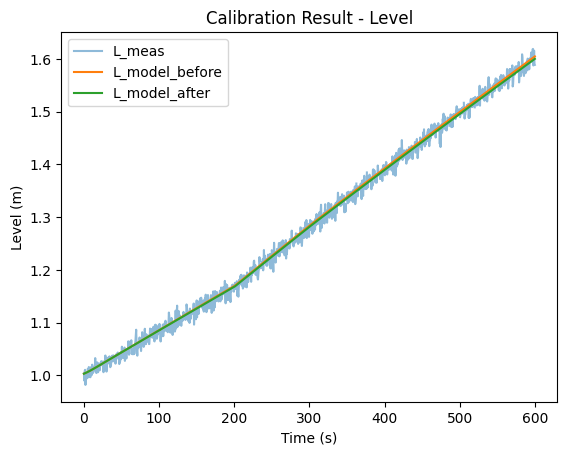

In [6]:
#Plot before vs after untuk level
import matplotlib.pyplot as plt

df_before = result["df_before"]
df_after = result["df_after"]

plt.figure()
plt.plot(df_log["t_s"], df_log["L_meas_m"], label="L_meas", alpha=0.5)
plt.plot(df_before["t_s"], df_before["L_m"], label="L_model_before")
plt.plot(df_after["t_s"], df_after["L_m"], label="L_model_after")
plt.xlabel("Time (s)")
plt.ylabel("Level (m)")
plt.title("Calibration Result - Level")
plt.legend()
plt.show()

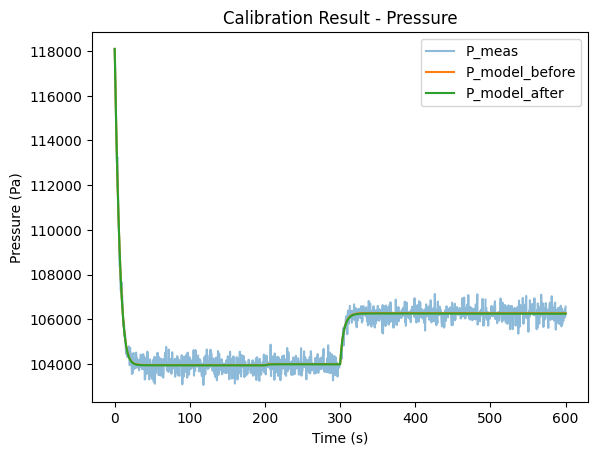

In [7]:
#Plot untuk pressure
plt.figure()
plt.plot(df_log["t_s"], df_log["P_meas_Pa"], label="P_meas", alpha=0.5)
plt.plot(df_before["t_s"], df_before["P_Pa"], label="P_model_before")
plt.plot(df_after["t_s"], df_after["P_Pa"], label="P_model_after")
plt.xlabel("Time (s)")
plt.ylabel("Pressure (Pa)")
plt.title("Calibration Result - Pressure")
plt.legend()
plt.show()

In [8]:
#Cek error
import numpy as np

# Hitung RMSE hanya pada data yang ada (non-NaN)
mask_L = ~df_log["L_meas_m"].isna()
mask_P = ~df_log["P_meas_Pa"].isna()

rmse_L_before = np.sqrt(np.mean((df_log.loc[mask_L, "L_meas_m"].to_numpy() - df_before.loc[mask_L, "L_m"].to_numpy())**2))
rmse_L_after  = np.sqrt(np.mean((df_log.loc[mask_L, "L_meas_m"].to_numpy() - df_after.loc[mask_L, "L_m"].to_numpy())**2))

rmse_P_before = np.sqrt(np.mean((df_log.loc[mask_P, "P_meas_Pa"].to_numpy() - df_before.loc[mask_P, "P_Pa"].to_numpy())**2))
rmse_P_after  = np.sqrt(np.mean((df_log.loc[mask_P, "P_meas_Pa"].to_numpy() - df_after.loc[mask_P, "P_Pa"].to_numpy())**2))

rmse_L_before, rmse_L_after, rmse_P_before, rmse_P_after

(np.float64(0.010329093538677038),
 np.float64(0.009992931934612325),
 np.float64(306.6027286792054),
 np.float64(306.2154728897476))